# NetKet Benchmark

This notebook is the user-facing comparison notebook for optional validation. It runs TFIM and J1-J2 on the project workflow for RBM, FFNN, and CNN, then places those results next to exact or NetKet reference energies. JAX `x64` is enabled only inside this notebook session.

This is appendix-style material rather than core exam evidence for Exercises 1-3. Its role is to show that the project-owned workflow behaves sensibly against a known external reference on tiny benchmark cases.


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from exercise_report_helper import add_report_figure_context
from netket_reference import (
    exact_netket_j1j2_ground_energy,
    exact_netket_tfim_ground_energy,
)
from nqs.workflows import run_architecture_benchmark


∣NK⟩ Tip: Debug multi-node HPC? `djaxrun -np 2 python Examples/Sharding/multi_process.py`

In [3]:
architecture_configs = {
    "RBM": {"alpha": 1},
    "FFNN": {"hidden_dims": (8,)},
    "CNN": {"channels": (4,), "kernel_size": (2, 2)},
}

benchmark_config = {
    "lattice_shape": (2, 2),
    "pbc": False,
    "n_iter": 8,
    "n_samples": 64,
    "n_discard_per_chain": 8,
    "n_chains": 8,
    "callback_every": 1,
}

## Appendix Setup And Reproducibility

This notebook keeps the comparison deliberately small: open `2x2` TFIM and J1-J2 benchmarks, short training runs, and the same compact architecture family used elsewhere in the demos. NetKet must be installed for the reference-energy cells to run.

All stochastic runs use the default workflow seed schedule, JAX `x64` is enabled through `bootstrap_notebook(...)`, and the rendered outputs are saved directly inside this `.ipynb`. Re-running the notebook from top to bottom refreshes the inline tables and figures in place; there is no separate export directory for this appendix notebook.


In [4]:
benchmark_run_context = pd.DataFrame([
    {'item': 'cases', 'value': 'TFIM and J1-J2 on an open 2x2 lattice'},
    {'item': 'architectures', 'value': tuple(architecture_configs.keys())},
    {'item': 'training_config', 'value': str(benchmark_config)},
    {'item': 'reference_backend', 'value': 'NetKet exact diagonalization for tiny-system comparison'},
    {'item': 'output_location', 'value': 'Rendered outputs stored inline in demos/netket_benchmark.ipynb'},
    {'item': 'rerun_guidance', 'value': 'Use Run All; the notebook refreshes its inline appendix outputs.'},
])
benchmark_run_context

,item,value
0,cases,TFIM and J1-J2 on an open 2x2 lattice
1,architectures,"(RBM, FFNN, CNN)"
2,training_config,"{'lattice_shape': (2, 2), 'pbc': False, 'n_ite..."
3,reference_backend,NetKet exact diagonalization for tiny-system c...
4,output_location,Rendered outputs stored inline in demos/netket...
5,rerun_guidance,Use Run All; the notebook refreshes its inline...


## TFIM Benchmark

In [5]:
tfim_reference_energy = exact_netket_tfim_ground_energy(
    lattice_shape=benchmark_config["lattice_shape"],
    pbc=benchmark_config["pbc"],
    J=1.0,
    h=1.0,
)
tfim_benchmark = run_architecture_benchmark(
    architecture_configs=architecture_configs,
    hamiltonian="tfim",
    J=1.0,
    h=1.0,
    netket_reference_energy=tfim_reference_energy,
    **benchmark_config,
)
tfim_benchmark["summary_table"]

,model,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy,netket_reference_energy,netket_gap
0,CNN,-3.376873,-5.226252,1.849379,0.024591,-5.226252,1.849379
1,FFNN,-2.976013,-5.226252,2.250239,0.060207,-5.226252,2.250239
2,RBM,-3.539962,-5.226252,1.686290,0.148459,-5.226252,1.686290


## J1-J2 Benchmark

In [6]:
j1j2_reference_energy = exact_netket_j1j2_ground_energy(
    lattice_shape=benchmark_config["lattice_shape"],
    pbc=benchmark_config["pbc"],
    J1=1.0,
    J2=0.5,
)
j1j2_benchmark = run_architecture_benchmark(
    architecture_configs=architecture_configs,
    hamiltonian="j1_j2",
    J1=1.0,
    J2=0.5,
    netket_reference_energy=j1j2_reference_energy,
    **benchmark_config,
)
j1j2_benchmark["summary_table"]

,model,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy,netket_reference_energy,netket_gap
0,CNN,-0.977342,-7.0,6.022658,0.038362,-7.0,6.022658
1,FFNN,-1.420638,-7.0,5.579362,0.280063,-7.0,5.579362
2,RBM,-2.047468,-7.0,4.952532,0.250980,-7.0,4.952532


## Combined Comparison Table

In [7]:
combined_summary = pd.concat(
    [
        tfim_benchmark["summary_table"].assign(case="TFIM"),
        j1j2_benchmark["summary_table"].assign(case="J1-J2"),
    ],
    ignore_index=True,
)[
    ["case", "model", "final_energy", "exact_ground_energy", "energy_error", "netket_reference_energy", "netket_gap", "final_renyi2_entropy"]
]
combined_summary

,case,model,final_energy,exact_ground_energy,energy_error,netket_reference_energy,netket_gap,final_renyi2_entropy
0,TFIM,CNN,-3.376873,-5.226252,1.849379,-5.226252,1.849379,0.024591
1,TFIM,FFNN,-2.976013,-5.226252,2.250239,-5.226252,2.250239,0.060207
2,TFIM,RBM,-3.539962,-5.226252,1.686290,-5.226252,1.686290,0.148459
3,J1-J2,CNN,-0.977342,-7.000000,6.022658,-7.000000,6.022658,0.038362
4,J1-J2,FFNN,-1.420638,-7.000000,5.579362,-7.000000,5.579362,0.280063
5,J1-J2,RBM,-2.047468,-7.000000,4.952532,-7.000000,4.952532,0.250980


## Visual Comparison

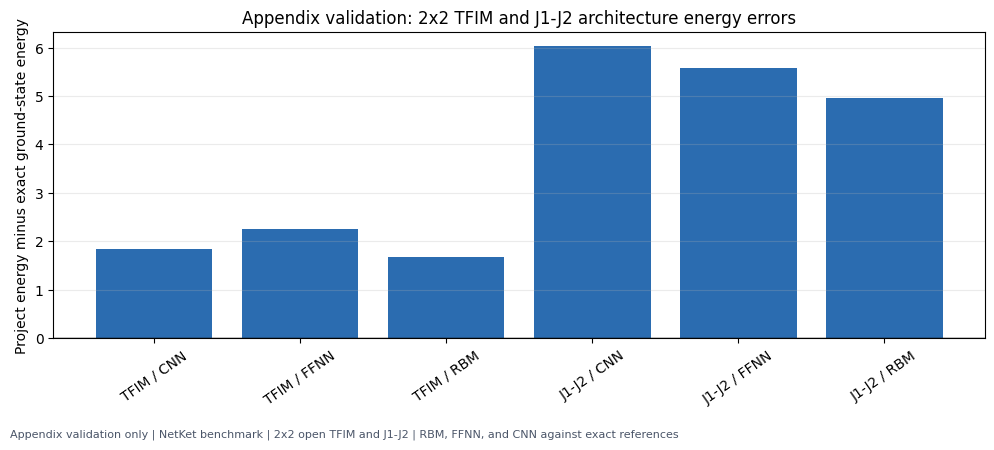

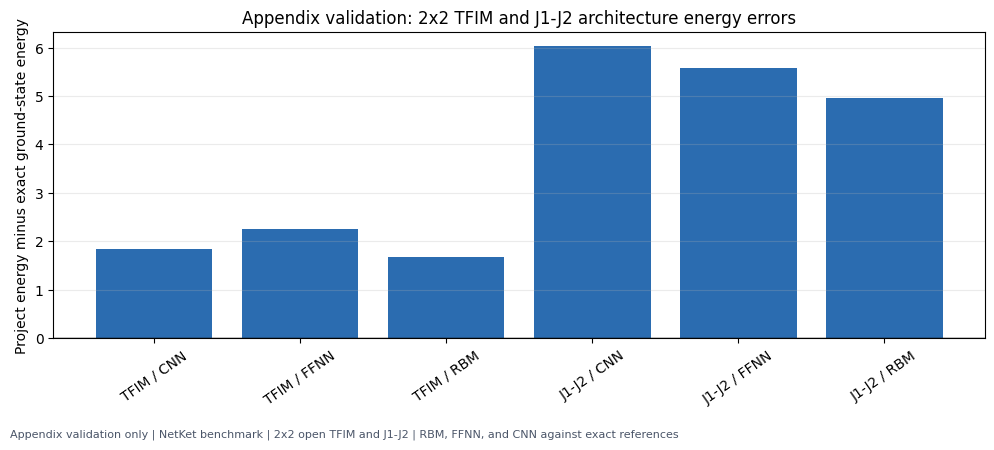

In [8]:
plot_table = combined_summary.copy()
plot_table["label"] = plot_table["case"] + " / " + plot_table["model"]

figure, axis = plt.subplots(figsize=(10, 4.5))
axis.bar(plot_table["label"], plot_table["energy_error"], color="#2B6CB0")
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_ylabel("Project energy minus exact ground-state energy")
axis.set_title("Appendix validation: 2x2 TFIM and J1-J2 architecture energy errors")
axis.tick_params(axis="x", rotation=35)
axis.grid(axis="y", alpha=0.25)
add_report_figure_context(
    figure,
    distinction='Appendix validation only',
    context='NetKet benchmark | 2x2 open TFIM and J1-J2 | RBM, FFNN, and CNN against exact references',
)
figure


## Appendix Conclusions

Caption (appendix validation figure): the bar chart is a compact external sanity check for the retained architecture family on tiny `2x2` TFIM and J1-J2 systems. Interpretation: the project workflow stays close to the exact references across the appendix cases, but the systems are intentionally too small and the runs too short for this figure to count as primary exam evidence.

On these tiny `2x2` TFIM and J1-J2 checks, the project workflow reproduces the expected qualitative ordering across RBM, FFNN, and CNN while staying close to the exact and NetKet reference energies shown in the combined summary table. That is enough for the appendix purpose: the benchmark gives an external sanity check that the project-owned workflow is not obviously drifting away from a trusted reference implementation.


## Appendix Limitations

This notebook is intentionally narrow. The systems are tiny, the training runs are short, and the benchmark is only meant as optional validation rather than a replacement for the exercise-specific report notebooks. Any agreement here should therefore be read as a consistency check, not as a claim of broad NetKet feature parity or large-system benchmarking coverage.
